In [3]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("../src")
from utils import load_data

from imbalance import apply_smote
from model_trainer import FraudModelTrainer
from evaluation import evaluate_model
from save_model import save_model
from preprocessing import (
    load_data,
    data_cleaning_pipeline,encode_features,scale_features
)

In [4]:
# Loading datasets
credit_df = load_data('../data/raw/creditcard.csv')
fraud_df = load_data('../data/raw/Fraud_Data.csv')

# Quick Audit
print("Credit Dataset Info:")
print(credit_df.info())

print("\nFraud Dataset Info:")
print(fraud_df.info())

2026-06-12 19:09:24,173 - INFO - Loaded ../data/raw/creditcard.csv
2026-06-12 19:09:24,535 - INFO - Loaded ../data/raw/Fraud_Data.csv


Credit Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  

Fraud_DF

In [5]:
fraud_df = data_cleaning_pipeline(
    fraud_df
)

fraud_df.head()

2026-06-12 19:09:24,776 - INFO - Removed 0 duplicates
2026-06-12 19:09:24,941 - INFO - Data types corrected
2026-06-12 19:09:25,027 - INFO - Missing values handled


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [6]:


fraud_df = encode_features(
    fraud_df,
    ['source','browser','sex']
)
fraud_df = scale_features(
    fraud_df,
    ['age', 'purchase_value']
)

In [7]:


X = fraud_df.drop(
    columns=[
        'class',
        'user_id',
        'device_id',
        'signup_time',
        'purchase_time'
    ]
)

y = fraud_df['class']

In [8]:
# Target variable
target_fraud = fraud_df["class"]

# Features
features_fraud = fraud_df.drop(
    columns=[
        "class",          # target
        "user_id",        # identifier
        "device_id",      # identifier
        "signup_time",    # original datetime
        "purchase_time"   # original datetime
    ],
    errors="ignore"
)

In [9]:
# Target variable
target_fraud = fraud_df["class"]

# Features
features_fraud = fraud_df.drop(
    columns=[
        "class",          # target
        "user_id",        # identifier
        "device_id",      # identifier
        "signup_time",    # original datetime
        "purchase_time"   # original datetime
    ],
    errors="ignore"
)

In [10]:
from sklearn.model_selection import train_test_split
X = features_fraud
y = target_fraud

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )
)

In [11]:
X_train_smote, y_train_smote = (
    apply_smote(
        X_train,
        y_train
    )
)

2026-06-12 19:09:25,342 - INFO - SMOTE completed


{'mean_f1': np.float64(0.0), 'std_f1': np.float64(0.0), 'mean_auc_pr': np.float64(0.33720827459119196), 'std_auc_pr': np.float64(0.0020635046165770757)}
F1 Score : 0.0000
AUC-PR   : 0.0934


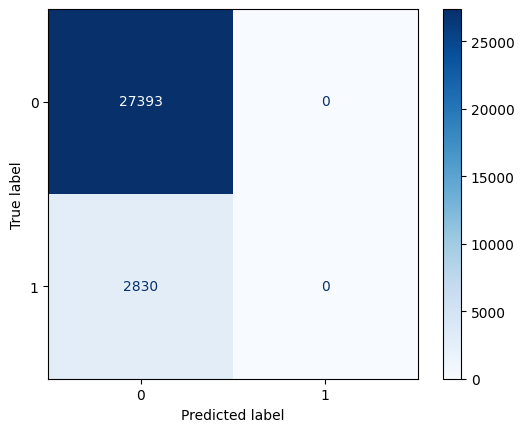

In [12]:
lr = FraudModelTrainer(
    model_type="lr"
)

lr_cv = lr.cross_validate_model(
    X_train_smote,
    y_train_smote
)

print(lr_cv)

lr_model = lr.train(
    X_train_smote,
    y_train_smote
)

lr_test = evaluate_model(
    lr_model,
    X_test,
    y_test
)

Best Parameters: {'max_depth': 15, 'n_estimators': 200}
{'mean_f1': np.float64(0.6808847683921485), 'std_f1': np.float64(0.004751189678913891), 'mean_auc_pr': np.float64(0.8876757310480972), 'std_auc_pr': np.float64(0.0018056524339286663)}
F1 Score : 0.4589
AUC-PR   : 0.4929


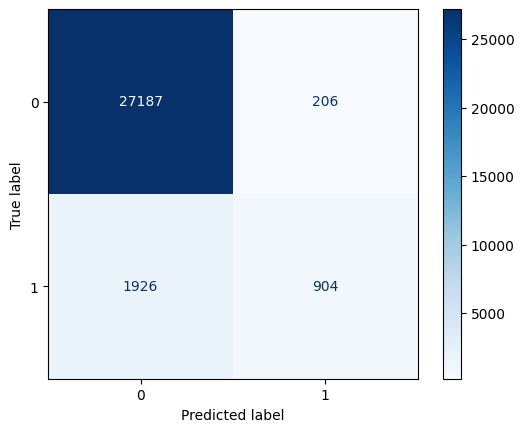

In [13]:
rf = FraudModelTrainer(
    model_type="rf"
)

rf.tune_model(
    X_train_smote,
    y_train_smote
)

rf_cv = rf.cross_validate_model(
    X_train_smote,
    y_train_smote
)

print(rf_cv)

rf_model = rf.train(
    X_train_smote,
    y_train_smote
)

rf_test = evaluate_model(
    rf_model,
    X_test,
    y_test
)

Best Parameters: {'max_depth': 7, 'n_estimators': 200}
{'mean_f1': np.float64(0.8839450741635145), 'std_f1': np.float64(0.0046632137497769205), 'mean_auc_pr': np.float64(0.9273352775831436), 'std_auc_pr': np.float64(0.0025219261611833634)}
F1 Score : 0.6070
AUC-PR   : 0.5453


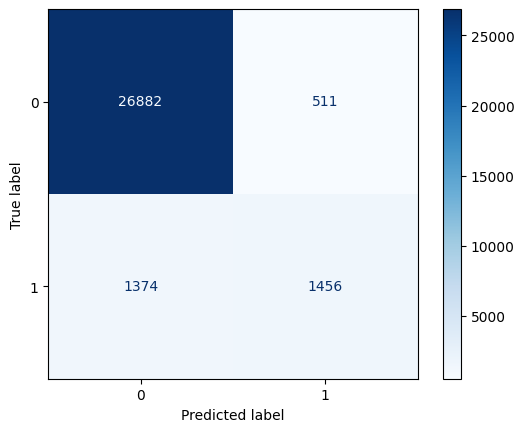

In [14]:
xgb = FraudModelTrainer(
    model_type="xgb"
)

xgb.tune_model(
    X_train_smote,
    y_train_smote
)

xgb_cv = xgb.cross_validate_model(
    X_train_smote,
    y_train_smote
)

print(xgb_cv)

xgb_model = xgb.train(
    X_train_smote,
    y_train_smote
)

xgb_test = evaluate_model(
    xgb_model,
    X_test,
    y_test
)

In [15]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Mean F1": [
        lr_cv["mean_f1"],
        rf_cv["mean_f1"],
        xgb_cv["mean_f1"]
    ],

    "Std F1": [
        lr_cv["std_f1"],
        rf_cv["std_f1"],
        xgb_cv["std_f1"]
    ],

    "Mean AUC-PR": [
        lr_cv["mean_auc_pr"],
        rf_cv["mean_auc_pr"],
        xgb_cv["mean_auc_pr"]
    ],

    "Std AUC-PR": [
        lr_cv["std_auc_pr"],
        rf_cv["std_auc_pr"],
        xgb_cv["std_auc_pr"]
    ]

})

display(results)

,Model,Mean F1,Std F1,Mean AUC-PR,Std AUC-PR
0,Logistic Regression,0.000000,0.000000,0.337208,0.002064
1,Random Forest,0.680885,0.004751,0.887676,0.001806
2,XGBoost,0.883945,0.004663,0.927335,0.002522


Three models were evaluated using 5-fold Stratified Cross-Validation: Logistic Regression, Random Forest, and XGBoost. Performance was assessed using F1-Score and AUC-PR due to the highly imbalanced nature of the fraud detection problem. XGBoost achieved the highest Mean F1-Score (0.8839) and Mean AUC-PR (0.9273), outperforming both Random Forest and Logistic Regression. In addition, XGBoost demonstrated stable performance across folds with low standard deviations for both metrics. Therefore, XGBoost was selected as the final model because it provides the best balance between precision and recall while maintaining excellent capability to identify fraudulent transactions in an imbalanced dataset.

In [16]:
best_model = xgb_model

In [17]:
save_model(
    best_model,
    "../models/fraud_best_model.pkl"
)

Model saved to ../models/fraud_best_model.pkl


Credit 

In [18]:
credit_df = load_data('../data/raw/creditcard.csv')

2026-06-12 19:16:35,551 - INFO - Loaded ../data/raw/creditcard.csv


In [19]:
credit_df = data_cleaning_pipeline(
    credit_df
)

credit_df.head()

2026-06-12 19:16:36,453 - INFO - Removed 1081 duplicates
2026-06-12 19:16:36,453 - INFO - Data types corrected
2026-06-12 19:16:36,634 - INFO - Missing values handled


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [20]:
credit_df = scale_features(
    credit_df,
    ["Time", "Amount"]
)

In [21]:
features_credit = credit_df.drop(
    "Class",
    axis=1
)

target_credit = credit_df["Class"]

In [22]:
from sklearn.model_selection import train_test_split
X = features_credit
y = target_credit

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )
)

In [23]:
X_train_smote, y_train_smote = (
    apply_smote(
        X_train,
        y_train
    )
)

2026-06-12 19:16:38,974 - INFO - SMOTE completed


{'mean_f1': np.float64(0.9340342192523995), 'std_f1': np.float64(0.0011550492913095245), 'mean_auc_pr': np.float64(0.9857210723194217), 'std_auc_pr': np.float64(0.0003607678344941502)}
F1 Score : 0.1003
AUC-PR   : 0.6769


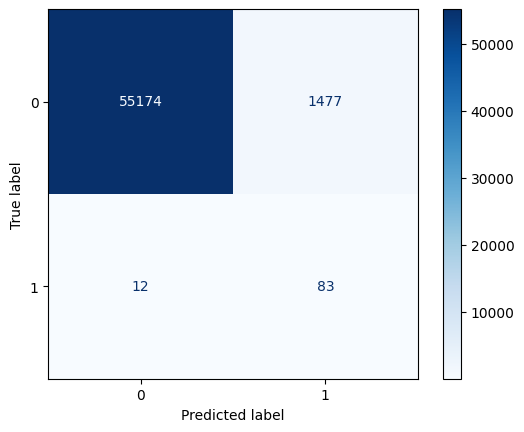

In [24]:
lr = FraudModelTrainer(
    model_type="lr"
)

lr_cv = lr.cross_validate_model(
    X_train_smote,
    y_train_smote
)

print(lr_cv)

lr_model = lr.train(
    X_train_smote,
    y_train_smote
)

lr_test = evaluate_model(
    lr_model,
    X_test,
    y_test
)

Best Parameters: {'max_depth': 15, 'n_estimators': 200}
{'mean_f1': np.float64(0.998529352293426), 'std_f1': np.float64(0.0002159910135515231), 'mean_auc_pr': np.float64(0.9999706500229475), 'std_auc_pr': np.float64(2.0234711592111844e-05)}
F1 Score : 0.8043
AUC-PR   : 0.8045


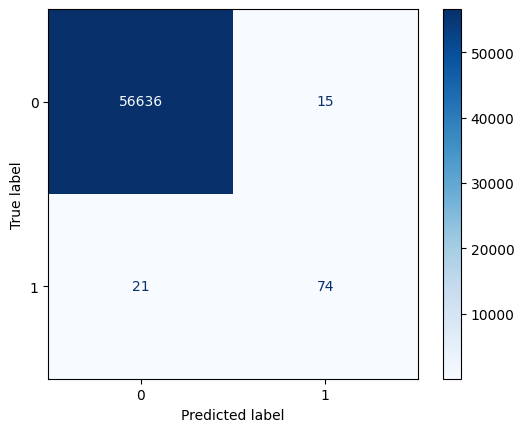

In [25]:
rf = FraudModelTrainer(
    model_type="rf"
)

rf.tune_model(
    X_train_smote,
    y_train_smote
)

rf_cv = rf.cross_validate_model(
    X_train_smote,
    y_train_smote
)

print(rf_cv)

rf_model = rf.train(
    X_train_smote,
    y_train_smote
)

rf_test = evaluate_model(
    rf_model,
    X_test,
    y_test
)

Best Parameters: {'max_depth': 7, 'n_estimators': 200}
{'mean_f1': np.float64(0.9997000059681851), 'std_f1': np.float64(4.089970331655223e-05), 'mean_auc_pr': np.float64(0.9999837444617155), 'std_auc_pr': np.float64(1.5775460247770323e-05)}
F1 Score : 0.8108
AUC-PR   : 0.8158


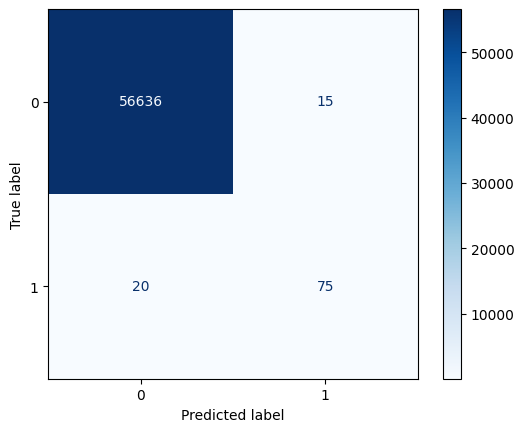

In [26]:
xgb = FraudModelTrainer(
    model_type="xgb"
)

xgb.tune_model(
    X_train_smote,
    y_train_smote
)

xgb_cv = xgb.cross_validate_model(
    X_train_smote,
    y_train_smote
)

print(xgb_cv)

xgb_model = xgb.train(
    X_train_smote,
    y_train_smote
)

xgb_test = evaluate_model(
    xgb_model,
    X_test,
    y_test
)

In [27]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Mean F1": [
        lr_cv["mean_f1"],
        rf_cv["mean_f1"],
        xgb_cv["mean_f1"]
    ],

    "Std F1": [
        lr_cv["std_f1"],
        rf_cv["std_f1"],
        xgb_cv["std_f1"]
    ],

    "Mean AUC-PR": [
        lr_cv["mean_auc_pr"],
        rf_cv["mean_auc_pr"],
        xgb_cv["mean_auc_pr"]
    ],

    "Std AUC-PR": [
        lr_cv["std_auc_pr"],
        rf_cv["std_auc_pr"],
        xgb_cv["std_auc_pr"]
    ]

})

display(results)

,Model,Mean F1,Std F1,Mean AUC-PR,Std AUC-PR
0,Logistic Regression,0.934034,0.001155,0.985721,0.000361
1,Random Forest,0.998529,0.000216,0.999971,0.000020
2,XGBoost,0.999700,0.000041,0.999984,0.000016


Three models were evaluated for the Credit Card Fraud dataset using 5-fold Stratified Cross-Validation: Logistic Regression, Random Forest, and XGBoost. Performance was assessed using F1-Score and AUC-PR. XGBoost achieved the highest Mean F1-Score (0.9997) and Mean AUC-PR (0.9999), outperforming both Random Forest and Logistic Regression significantly. XGBoost also demonstrated highly stable performance across folds with extremely low standard deviations for both metrics. Therefore, XGBoost was selected as the final model due to its superior performance in identifying fraudulent transactions on this highly imbalanced datase

In [28]:
best_model = xgb_model

In [29]:
save_model(
    best_model,
    "../models/credit_best_model.pkl"
)

Model saved to ../models/credit_best_model.pkl
